In [1]:
from helpers import multiple_targets_env, cliff_env, dynamic_target_env
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [4]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

multiple_target_goals = [(4, 0), (4, 6), (3, 3)]
multiple_target_rewards = [2, 8, 3]

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 20 # used for episodic evaluation


In [5]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details

SlipperyEnv = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)

MultipleTargetsEnv = multiple_targets_env.MultipleTargetSlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state,
                         slip_prob=slip_prob, step_reward=step_reward,
                         max_steps=max_steps_in_env, seed=random_seed, goals=multiple_target_goals, goal_rewards=multiple_target_rewards)

CliffEnv = cliff_env.CliffSlipperyGridWorld(slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)

DynamicTargetEnv = dynamic_target_env.DynamicTargetSlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state,
                                                                     slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)

env = SlipperyEnv

s = env.reset() # prepared clean environment

num_states = env.num_states # number of unique states
V  = np.zeros(num_states) # initialization for V(s)

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
# try looking at these functions' docs for inspiration
iter_num = max_number_iterations
for i in range(max_number_iterations):
    delta = 0
    V_cp = V.copy()
    for state in range(len(V)):
        if env.is_terminal_state(state):
            continue

        max_for_action = -np.inf
        for action in range(4):
            curr_sum = 0
            for probability, next_state in env.get_transition_distribution(state, action):
                curr_sum += probability * (env.reward(state, action, next_state) + gamma * V_cp[next_state])
            max_for_action = max(max_for_action, curr_sum)

        V_current = V_cp[state]
        V[state] = max_for_action
        delta = max(delta, np.abs(V_current - V[state]))

    if delta < threshold:
        iter_num = i
        break

print(iter_num)

33


In [6]:
def greedy_policy_from_Q(Q: np.ndarray) -> np.ndarray:
	policy = np.zeros(num_states, dtype=int)
	for state in range(num_states):
		policy[state] = int(np.argmax(Q[state]))
	return policy

In [7]:
import random

num_episodes = 40000

Q = np.zeros((num_states, len(ACTIONS)))
epsilon = 1
epsilon_min = 0.01
epsilon_decay = 0.95
alpha = 0.1

def epsilon_greedy_policy(Q, state, epsilon) -> int:
	if random.random() < epsilon:
		return random.choice(ACTIONS)

	return int(np.argmax(Q[state]))


for episode_num in range(num_episodes):
	print(f"\rProgress: {(episode_num / num_episodes * 100):6.2f}%", end="")

	state = env.reset()
	done = False

	while not done:
		action = epsilon_greedy_policy(Q, state, epsilon)
		next_state, reward, done, _ = env.step(action)
		Q[state, action] = Q[state, action] + alpha * (reward + (1 - done) * gamma * np.max(Q[next_state]) - Q[state,
		action])
		state = next_state

	epsilon = max(epsilon_min, epsilon * epsilon_decay)

Progress: 100.00%

In [8]:
pi_Q = greedy_policy_from_Q(Q)

In [9]:
import random

num_episodes = 40000

Q_sarsa = np.zeros((num_states, len(ACTIONS)))
epsilon = 1
epsilon_min = 0.01
epsilon_decay = 0.95
alpha = 0.1


def epsilon_greedy_policy(Q, state, epsilon) -> int:
    if random.random() < epsilon:
        return random.choice(ACTIONS)

    return int(np.argmax(Q[state]))


for episode_num in range(num_episodes):
    print(f"\rProgress: {(episode_num / num_episodes * 100):6.2f}%", end="")

    state = env.reset()
    done = False

    action = epsilon_greedy_policy(Q_sarsa, state, epsilon)

    while not done:
        next_state, reward, done, _ = env.step(action)
        next_action = epsilon_greedy_policy(Q_sarsa, next_state, epsilon)

        Q_sarsa[state, action] = Q_sarsa[state, action] + alpha * (
            reward + (1 - done) * gamma * Q_sarsa[next_state, next_action] - Q_sarsa[state, action]
        )

        state = next_state
        action = next_action

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

Progress: 100.00%

In [10]:
pi_Sarsa = greedy_policy_from_Q(Q_sarsa)

In [11]:
from dynaq.dyna_q import DynaQAgent

num_episodes = 300

epsilon = 1
epsilon_min = 0.01
epsilon_decay = 0.95
alpha = 0.1

num_sim_iter = 50

agent = DynaQAgent(num_episodes, num_sim_iter, epsilon, epsilon_min, epsilon_decay, alpha, gamma, env, num_states, list(ACTIONS))

agent.run()

Progress:  99.67%

In [12]:
pi_DynaQ = greedy_policy_from_Q(agent.Q)

In [13]:
gif_fps = 6
visual_path = "../visuals/slippery/"

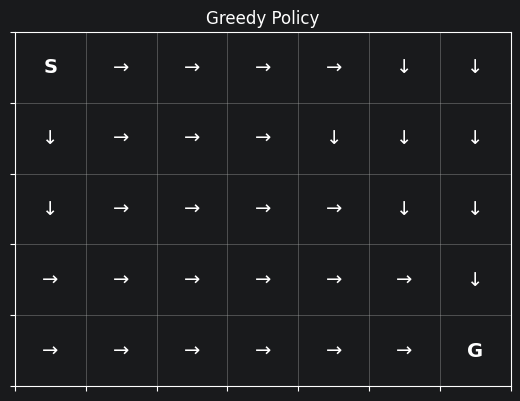

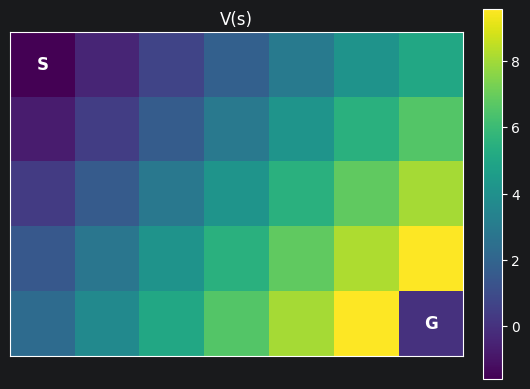

{'avg_return': -0.92, 'std_return': 1.9271, 'success_rate': 1.0, 'avg_steps': 11.92}


In [14]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=visual_path + policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=visual_path + value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=visual_path + gif_name, fps=gif_fps)

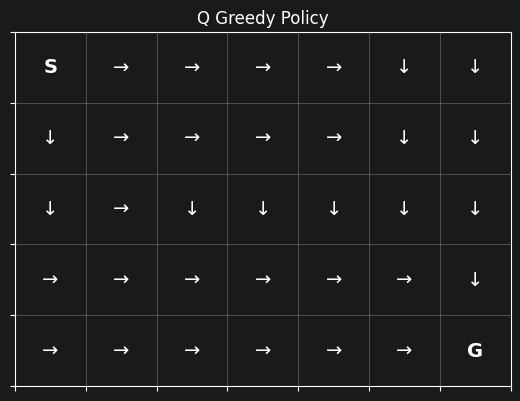

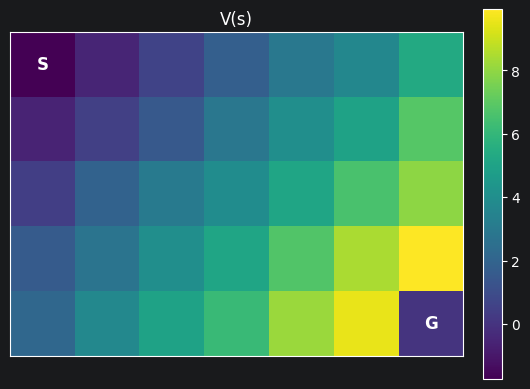

{'avg_return': -0.96, 'std_return': 1.9387, 'success_rate': 1.0, 'avg_steps': 11.96}


In [15]:
policy_plot_name = "policy_Q.png"
value_plot_name = "value_Q.png"
gif_name = "episode_Q.gif"
n_val_episodes = 50

env.reset()

# Greedy policy from Q(s,a)
pi = pi_Q

# V from policy and Q
states = np.arange(num_states)
V = Q[states, pi]

# visualize policy and V(s)
plot_policy(env, pi, filename=visual_path + policy_plot_name, title="Q Greedy Policy")
plot_value_heatmap(env, V, filename=visual_path + value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=visual_path + gif_name, fps=gif_fps)

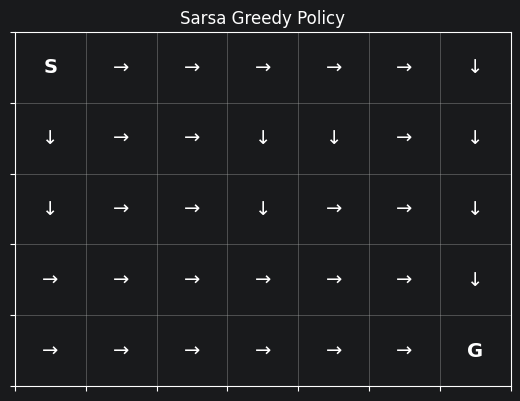

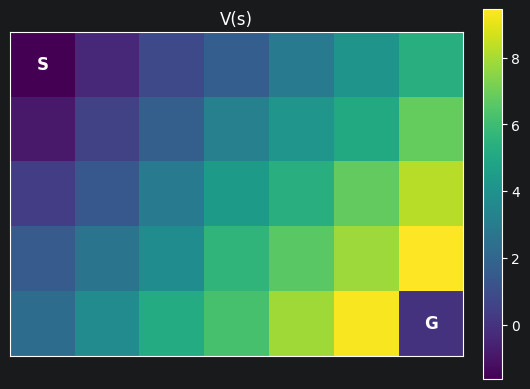

{'avg_return': -1.14, 'std_return': 1.9597, 'success_rate': 1.0, 'avg_steps': 12.14}


In [16]:
policy_plot_name = "policy_Q_sarsa.png"
value_plot_name = "value_Q_sarsa.png"
gif_name = "episode_Q_sarsa.gif"
n_val_episodes = 50

env.reset()

# Greedy policy from Q(s,a)
pi = pi_Sarsa

# V from policy and Q
states = np.arange(num_states)
V = Q_sarsa[states, pi]

# visualize policy and V(s)
plot_policy(env, pi, filename=visual_path + policy_plot_name, title="Sarsa Greedy Policy")
plot_value_heatmap(env, V, filename=visual_path + value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=visual_path + gif_name, fps=gif_fps)

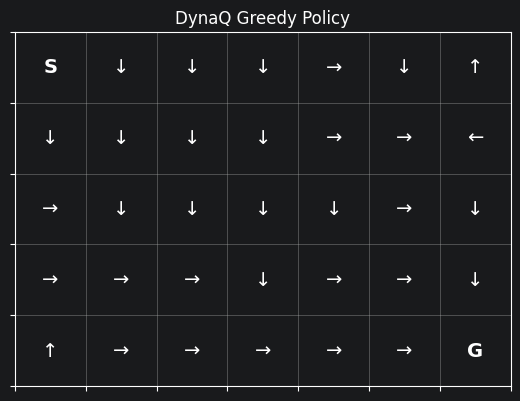

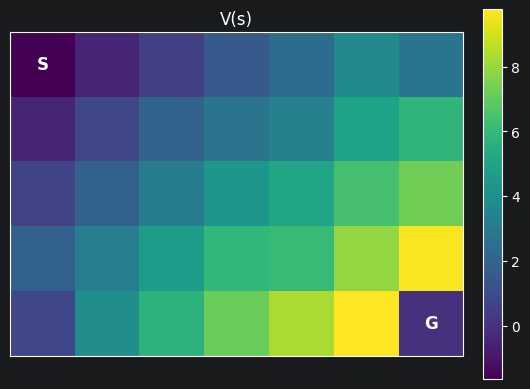

{'avg_return': -1.72, 'std_return': 2.3413, 'success_rate': 1.0, 'avg_steps': 12.72}


In [17]:
policy_plot_name = "policy_dynaQ.png"
value_plot_name = "value_dynaQ.png"
gif_name = "episode_dynaQ.gif"
n_val_episodes = 50

env.reset()

# Greedy policy from Q(s,a)
pi = pi_DynaQ

# V from policy and Q
states = np.arange(num_states)
V = agent.Q[states, pi]

# visualize policy and V(s)
plot_policy(env, pi, filename=visual_path + policy_plot_name, title="DynaQ Greedy Policy")
plot_value_heatmap(env, V, filename=visual_path + value_plot_name, title="V(s)")
plt.close("all")


# evaluate deterministic policy over multiple episodes
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=visual_path + gif_name, fps=gif_fps)